In [49]:
!nvidia-smi

Fri May  1 20:10:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.211.01             Driver Version: 570.211.01     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H200                    Off |   00000000:03:04.0 Off |                   On |
| N/A   35C    P0            121W /  700W |                  N/A   |     N/A      Default |
|                                         |                        |              Enabled |
+-----------------------------------------+-----

In [50]:
# Lokal calisma: Colab drive mount kullanilmiyor.


In [51]:
# Dataset path resolution (lokal)
# Veri kumesi yolu lokal diskten okunur.
import os
from pathlib import Path

DATA_ROOT = Path("/home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/dataset/2x_augmented_coco_dataset/dataset_augmented")


In [52]:
!pip install pytorch-ignite openpyxl pandas


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [53]:
import random
import torch
import ignite

import random, numpy as np, torch

seed = 0
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)


In [54]:
torch.__version__, ignite.__version__

('2.5.1+cu124', '0.5.4')

In [55]:
import torch
import torch.nn as nn


class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)


class Flatten(nn.Module):
    def forward(self, x):
        return x.reshape(x.shape[0], -1)

Now let's define `SqueezeExcitation` module

In [56]:
class SqueezeExcitation(nn.Module):
    def __init__(self, inplanes, se_planes):
        super(SqueezeExcitation, self).__init__()
        self.reduce_expand = nn.Sequential(
            nn.Conv2d(inplanes, se_planes, kernel_size=1, stride=1, padding=0, bias=True),
            Swish(),
            nn.Conv2d(se_planes, inplanes, kernel_size=1, stride=1, padding=0, bias=True),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x_se = torch.mean(x, dim=(-2, -1), keepdim=True)
        x_se = self.reduce_expand(x_se)
        return x_se * x

In [57]:
from torch.nn import functional as F


class MBConv(nn.Module):
    def __init__(self, inplanes, planes, kernel_size, stride, expand_rate=1.0, se_rate=0.25, drop_connect_rate=0.2):
        super(MBConv, self).__init__()

        expand_planes = int(inplanes * expand_rate)
        se_planes = max(1, int(inplanes * se_rate))

        self.expansion_conv = None
        if expand_rate > 1.0:
            self.expansion_conv = nn.Sequential(
                nn.Conv2d(inplanes, expand_planes, kernel_size=1, stride=1, padding=0, bias=False),
                nn.BatchNorm2d(expand_planes, momentum=0.01, eps=1e-3),
                Swish(),
            )
            inplanes = expand_planes

        self.depthwise_conv = nn.Sequential(
            nn.Conv2d(
                inplanes,
                expand_planes,
                kernel_size=kernel_size,
                stride=stride,
                padding=kernel_size // 2,
                groups=expand_planes,
                bias=False,
            ),
            nn.BatchNorm2d(expand_planes, momentum=0.01, eps=1e-3),
            Swish(),
        )

        self.squeeze_excitation = SqueezeExcitation(expand_planes, se_planes)

        self.project_conv = nn.Sequential(
            nn.Conv2d(expand_planes, planes, kernel_size=1, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(planes, momentum=0.01, eps=1e-3),
        )

        self.with_skip = stride == 1
        self.drop_connect_rate = drop_connect_rate

    def _drop_connect(self, x):
        keep_prob = 1.0 - self.drop_connect_rate
        drop_mask = torch.rand(x.shape[0], 1, 1, 1) + keep_prob
        drop_mask = drop_mask.type_as(x)
        drop_mask.floor_()
        return drop_mask * x / keep_prob

    def forward(self, x):
        z = x
        if self.expansion_conv is not None:
            x = self.expansion_conv(x)

        x = self.depthwise_conv(x)
        x = self.squeeze_excitation(x)
        x = self.project_conv(x)

        # Add identity skip
        if x.shape == z.shape and self.with_skip:
            if self.training and self.drop_connect_rate is not None:
                x = self._drop_connect(x)
            x += z
        return x

And finally, we can implement generic `EfficientNet`:

In [58]:
from collections import OrderedDict
import math


def init_weights(module):
    if isinstance(module, nn.Conv2d):
        nn.init.kaiming_normal_(module.weight, a=0, mode="fan_out")
    elif isinstance(module, nn.Linear):
        init_range = 1.0 / math.sqrt(module.weight.shape[1])
        nn.init.uniform_(module.weight, a=-init_range, b=init_range)


class EfficientNet(nn.Module):
    def _setup_repeats(self, num_repeats):
        return int(math.ceil(self.depth_coefficient * num_repeats))

    def _setup_channels(self, num_channels):
        num_channels *= self.width_coefficient
        new_num_channels = math.floor(num_channels / self.divisor + 0.5) * self.divisor
        new_num_channels = max(self.divisor, new_num_channels)
        if new_num_channels < 0.9 * num_channels:
            new_num_channels += self.divisor
        return new_num_channels

    def __init__(
        self,
        num_classes=100,
        width_coefficient=1.0,
        depth_coefficient=1.0,
        se_rate=0.25,
        dropout_rate=0.2,
        drop_connect_rate=0.2,
    ):
        super(EfficientNet, self).__init__()

        self.width_coefficient = width_coefficient
        self.depth_coefficient = depth_coefficient
        self.divisor = 8

        list_channels = [32, 16, 24, 40, 80, 112, 192, 320, 1280]
        list_channels = [self._setup_channels(c) for c in list_channels]

        list_num_repeats = [1, 2, 2, 3, 3, 4, 1]
        list_num_repeats = [self._setup_repeats(r) for r in list_num_repeats]

        expand_rates = [1, 6, 6, 6, 6, 6, 6]
        strides = [1, 2, 2, 2, 1, 2, 1]
        kernel_sizes = [3, 3, 5, 3, 5, 5, 3]

        # Define stem:
        self.stem = nn.Sequential(
            nn.Conv2d(3, list_channels[0], kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(list_channels[0], momentum=0.01, eps=1e-3),
            Swish(),
        )

        # Define MBConv blocks
        blocks = []
        counter = 0
        num_blocks = sum(list_num_repeats)
        for idx in range(7):
            num_channels = list_channels[idx]
            next_num_channels = list_channels[idx + 1]
            num_repeats = list_num_repeats[idx]
            expand_rate = expand_rates[idx]
            kernel_size = kernel_sizes[idx]
            stride = strides[idx]
            drop_rate = drop_connect_rate * counter / num_blocks

            name = "MBConv{}_{}".format(expand_rate, counter)
            blocks.append(
                (
                    name,
                    MBConv(
                        num_channels,
                        next_num_channels,
                        kernel_size=kernel_size,
                        stride=stride,
                        expand_rate=expand_rate,
                        se_rate=se_rate,
                        drop_connect_rate=drop_rate,
                    ),
                )
            )
            counter += 1
            for i in range(1, num_repeats):
                name = "MBConv{}_{}".format(expand_rate, counter)
                drop_rate = drop_connect_rate * counter / num_blocks
                blocks.append(
                    (
                        name,
                        MBConv(
                            next_num_channels,
                            next_num_channels,
                            kernel_size=kernel_size,
                            stride=1,
                            expand_rate=expand_rate,
                            se_rate=se_rate,
                            drop_connect_rate=drop_rate,
                        ),
                    )
                )
                counter += 1

        self.blocks = nn.Sequential(OrderedDict(blocks))

        # Define head
        self.head = nn.Sequential(
            nn.Conv2d(list_channels[-2], list_channels[-1], kernel_size=1, bias=False),
            nn.BatchNorm2d(list_channels[-1], momentum=0.01, eps=1e-3),
            Swish(),
            nn.AdaptiveAvgPool2d(1),
            Flatten(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(list_channels[-1], num_classes),
        )

        self.apply(init_weights)

    def forward(self, x):
        f = self.stem(x)
        f = self.blocks(f)
        y = self.head(f)
        return y

All EfficientNet models can be defined using the following parametrization:
```
# (width_coefficient, depth_coefficient, resolution, dropout_rate)
'efficientnet-b0': (1.0, 1.0, 224, 0.2),
'efficientnet-b1': (1.0, 1.1, 240, 0.2),
'efficientnet-b2': (1.1, 1.2, 260, 0.3),
'efficientnet-b3': (1.2, 1.4, 300, 0.3),
'efficientnet-b4': (1.4, 1.8, 380, 0.4),
'efficientnet-b5': (1.6, 2.2, 456, 0.4),
'efficientnet-b6': (1.8, 2.6, 528, 0.5),
'efficientnet-b7': (2.0, 3.1, 600, 0.5),
```    
Let's define and train the third one: `EfficientNet-B0`

In [59]:
model = EfficientNet(num_classes=1000, width_coefficient=1.0, depth_coefficient=1.0, dropout_rate=0.2)

Number of parameters:

In [60]:
def print_num_params(model, display_all_modules=False):
    total_num_params = 0
    for n, p in model.named_parameters():
        num_params = 1
        for s in p.shape:
            num_params *= s
        if display_all_modules:
            print("{}: {}".format(n, num_params))
        total_num_params += num_params
    print("-" * 50)
    print("Total number of parameters: {:.2e}".format(total_num_params))


print_num_params(model)

--------------------------------------------------
Total number of parameters: 5.29e+06


### Load pretrained weights

Let's load pretrained weights and check the model on a single image.

In [61]:
!mkdir /tmp/efficientnet_weights
!wget http://storage.googleapis.com/public-models/efficientnet-b0-08094119.pth -O/tmp/efficientnet_weights/efficientnet-b0-08094119.pth

mkdir: cannot create directory ‘/tmp/efficientnet_weights’: File exists
--2026-05-01 20:10:03--  http://storage.googleapis.com/public-models/efficientnet-b0-08094119.pth
Resolving storage.googleapis.com (storage.googleapis.com)... 172.217.21.251, 172.217.20.91, 172.217.18.187, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|172.217.21.251|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 21383481 (20M) [application/octet-stream]
Saving to: ‘/tmp/efficientnet_weights/efficientnet-b0-08094119.pth’

/tmp/efficientnet_w 100%[===================>]  20.39M  22.4MB/s    in 0.9s    

2026-05-01 20:10:04 (22.4 MB/s) - ‘/tmp/efficientnet_weights/efficientnet-b0-08094119.pth’ saved [21383481/21383481]



In [62]:
from collections import OrderedDict

model_state = torch.load("/tmp/efficientnet_weights/efficientnet-b0-08094119.pth")

# A basic remapping is required
mapping = {k: v for k, v in zip(model_state.keys(), model.state_dict().keys())}
mapped_model_state = OrderedDict([(mapping[k], v) for k, v in model_state.items()])

model.load_state_dict(mapped_model_state, strict=False)

/tmp/ipykernel_2248820/1189015579.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_state = torch.load("/tmp/efficientnet_weights/efficientnet-b0-08094119.pth")


<All keys matched successfully>

In [63]:
# === PATH SETUP (unconditional) ===
# Bu hucre hangi siradan calistirilirsa calistirilsin path'leri kurar (lokal).
from pathlib import Path

DATA_ROOT = Path("/home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/dataset/2x_augmented_coco_dataset/dataset_augmented")

assert DATA_ROOT.exists(), f"DATA_ROOT missing: {DATA_ROOT}"

TRAIN_ANN = DATA_ROOT / "train" / "_annotations.coco.json"
VAL_ANN   = DATA_ROOT / "val"   / "_annotations.coco.json"
TEST_ANN  = DATA_ROOT / "test"  / "_annotations.coco.json"
TRAIN_IMG = DATA_ROOT / "train" / "images"
VAL_IMG   = DATA_ROOT / "val"   / "images"
TEST_IMG  = DATA_ROOT / "test"  / "images"

for p in [TRAIN_ANN, VAL_ANN, TEST_ANN, TRAIN_IMG, VAL_IMG, TEST_IMG]:
    assert p.exists(), f"missing: {p}"
print(f"PATHS OK -> {DATA_ROOT}")

# COCO bbox classifier dataset (thermal: Person / Car / OtherVehicle)
# Her annotation bir bbox kirpima donusur, EfficientNet siniflandirici girisi olur.
import json as _json
from PIL import Image
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision.transforms import Compose, Resize, RandomCrop, RandomHorizontalFlip, ToTensor, Normalize
from PIL.Image import BICUBIC


class CocoBBoxClassifier(Dataset):
    # ann_path: COCO JSON. images_dir: image klasoru. transform: torchvision transforms.
    def __init__(self, ann_path, images_dir, transform=None, min_side=4):
        with open(ann_path, "r") as f:
            data = _json.load(f)
        self.images_dir = Path(images_dir)
        self.transform  = transform

        cats = sorted(data["categories"], key=lambda c: c["id"])
        self.cat_id_to_idx = {c["id"]: i for i, c in enumerate(cats)}
        self.class_names   = [c["name"] for c in cats]

        id_to_file = {im["id"]: im["file_name"] for im in data["images"]}

        self.samples = []
        for ann in data["annotations"]:
            x, y, w, h = ann["bbox"]
            if w < min_side or h < min_side:
                continue
            self.samples.append((id_to_file[ann["image_id"]],
                                 (float(x), float(y), float(w), float(h)),
                                 self.cat_id_to_idx[ann["category_id"]]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fname, (x, y, w, h), cls = self.samples[idx]
        img  = Image.open(self.images_dir / fname).convert("RGB")
        crop = img.crop((x, y, x + w, y + h))
        if self.transform is not None:
            crop = self.transform(crop)
        return crop, cls


train_transform = Compose([
    Resize((256, 256), BICUBIC),
    RandomCrop(224),
    RandomHorizontalFlip(),
    ToTensor(),
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transform = Compose([
    Resize((224, 224), BICUBIC),
    ToTensor(),
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = CocoBBoxClassifier(TRAIN_ANN, TRAIN_IMG, transform=train_transform)
val_dataset   = CocoBBoxClassifier(VAL_ANN,   VAL_IMG,   transform=test_transform)
test_dataset  = CocoBBoxClassifier(TEST_ANN,  TEST_IMG,  transform=test_transform)

CLASS_NAMES = train_dataset.class_names
NUM_CLASSES = len(CLASS_NAMES)

train_eval_indices = [random.randint(0, len(train_dataset) - 1)
                      for _ in range(min(len(val_dataset), len(train_dataset)))]
train_eval_dataset = Subset(train_dataset, train_eval_indices)

print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"Train: {len(train_dataset)}  Val: {len(val_dataset)}  Test: {len(test_dataset)}  TrainEval: {len(train_eval_dataset)}")


PATHS OK -> /home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/dataset/2x_augmented_coco_dataset/dataset_augmented
Classes (3): ['Person', 'Car', 'OtherVehicle']
Train: 570171  Val: 8269  Test: 138247  TrainEval: 8269


In [64]:
# GPU'ya gore batch + workers (T4 = 16GB, A100 = 40GB+).
import torch as _torch

_gpu_name = _torch.cuda.get_device_name(0) if _torch.cuda.is_available() else ""
print(f"GPU: {_gpu_name}")


batch_size  = 256
num_workers = 4


print(f"batch_size={batch_size}  num_workers={num_workers}")

train_loader = DataLoader(
    train_dataset, batch_size=batch_size, num_workers=num_workers,
    shuffle=True, drop_last=True, pin_memory=True, persistent_workers=(num_workers > 0),
)

# Val seti birincil degerlendirme seti.
test_loader = DataLoader(
    val_dataset, batch_size=batch_size, num_workers=num_workers,
    shuffle=False, drop_last=False, pin_memory=True, persistent_workers=(num_workers > 0),
)

eval_train_loader = DataLoader(
    train_eval_dataset, batch_size=batch_size, num_workers=num_workers,
    shuffle=False, drop_last=False, pin_memory=True, persistent_workers=(num_workers > 0),
)


GPU: NVIDIA H200 MIG 1g.35gb
batch_size=256  num_workers=4


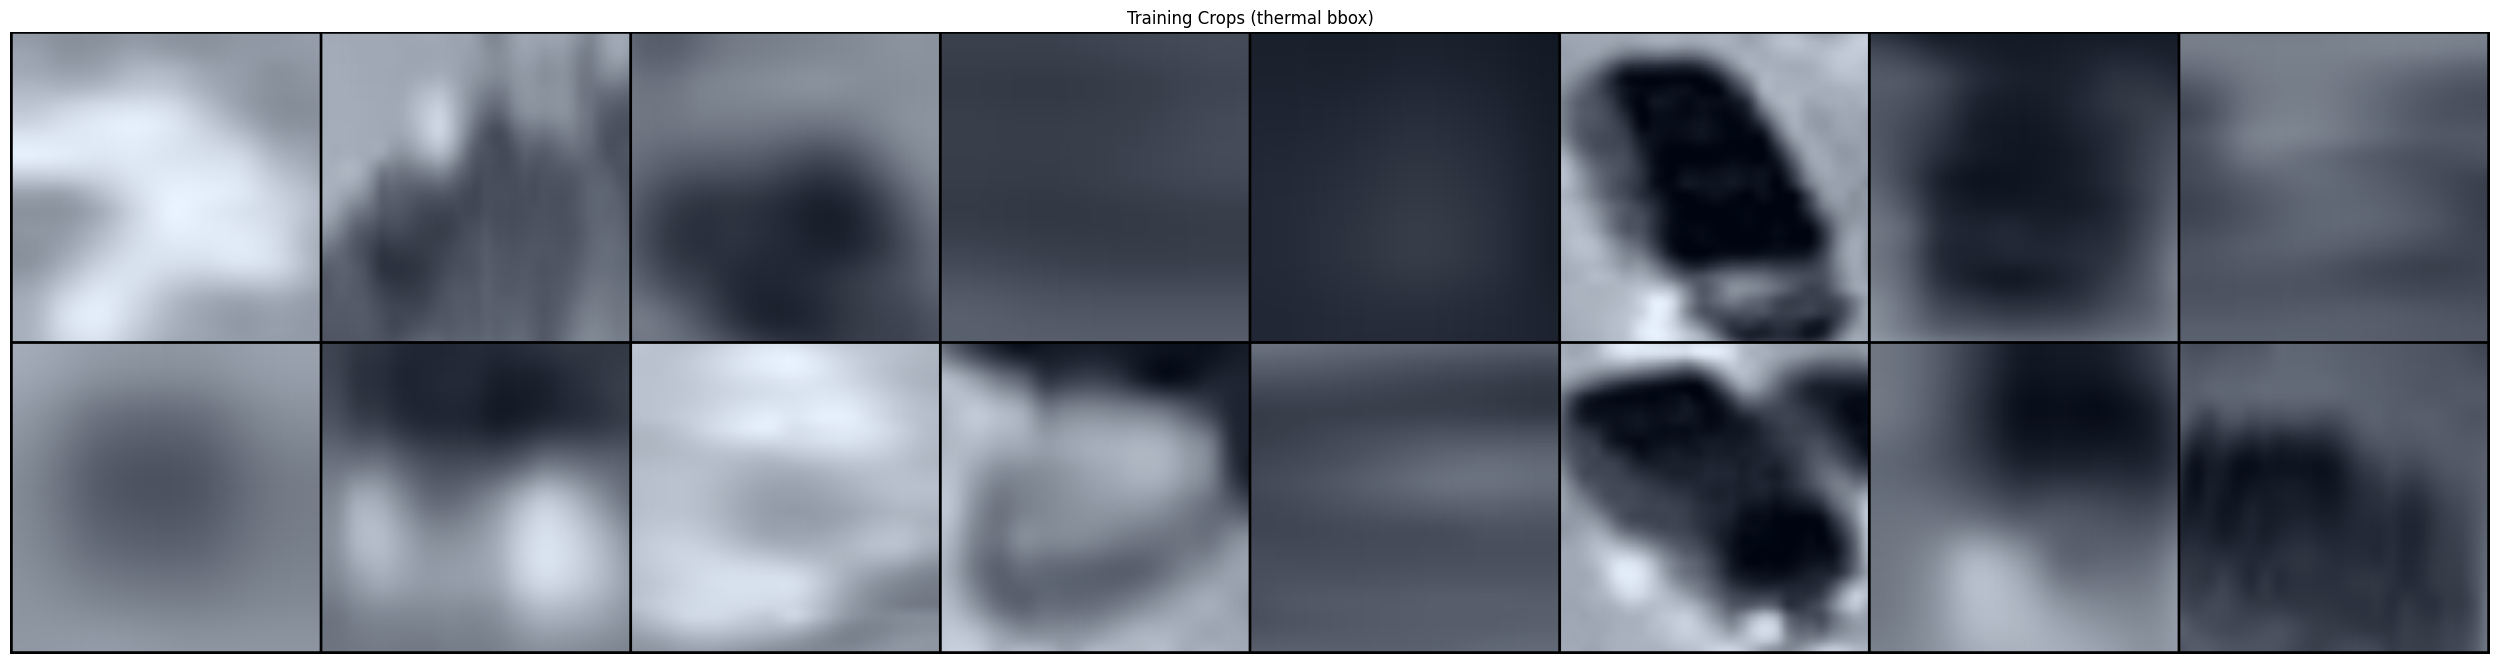

In [65]:
import matplotlib.pyplot as plt
# Preview: birkac batch goruntu
import torchvision.utils as vutils

batch = next(iter(train_loader))
plt.figure(figsize=(32, 32))
plt.axis("off")
plt.title("Training Crops (thermal bbox)")
plt.imshow(vutils.make_grid(batch[0][:16], padding=2, normalize=True).cpu().numpy().transpose((1, 2, 0)))

batch = None
torch.cuda.empty_cache()


## Finetunning model

As we are interested to finetune the model to CIFAR-100, we will replace the classification fully-connected layer (ImageNet-1000 vs CIFAR-100).

In [66]:
model.head[6].in_features, model.head[6].out_features

(1280, 1000)

In [67]:
model.head[6] = nn.Linear(1280, NUM_CLASSES)

In [68]:
model.head[6].in_features, model.head[6].out_features

(1280, 3)

Karma hassasiyet (mixed precision): `torch.cuda.amp` (native AMP). Hem T4 hem A100 destekler.

In [69]:
assert torch.cuda.is_available()
assert torch.backends.cudnn.enabled, "torch.cuda.amp requires cudnn backend."
torch.backends.cudnn.benchmark = True

device = "cuda"


In [70]:
model = model.to(device)

In [71]:
from itertools import chain

import torch.optim as optim
import torch.nn.functional as F


criterion = nn.CrossEntropyLoss()

lr = 0.01

optimizer = optim.SGD(
    [
        {
            "params": chain(model.stem.parameters(), model.blocks.parameters()),
            "lr": lr * 0.1,
        },
        {
            "params": model.head[:6].parameters(),
            "lr": lr * 0.2,
        },
        {"params": model.head[6].parameters(), "lr": lr},
    ],
    momentum=0.9,
    weight_decay=0.001,
    nesterov=True,
)

In [72]:
from torch.optim.lr_scheduler import ExponentialLR

lr_scheduler = ExponentialLR(optimizer, gamma=0.975)

In [73]:
# torch.cuda.amp ile karma hassasiyet (T4 + A100 destekler).
from torch.amp import GradScaler

scaler = GradScaler("cuda")


Next, let's define a single iteration function `update_fn`. This function is then used by `ignite.engine.Engine` to update model while running over the input data.

In [74]:
from ignite.utils import convert_tensor
from torch.amp import autocast


def update_fn(engine, batch):
    model.train()
    optimizer.zero_grad(set_to_none=True)

    x = convert_tensor(batch[0], device=device, non_blocking=True)
    y = convert_tensor(batch[1], device=device, non_blocking=True)

    with autocast("cuda"):
        y_pred = model(x)
        loss   = criterion(y_pred, y)

    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()

    return {"batchloss": loss.item()}


Let's check `update_fn`

In [75]:
batch = next(iter(train_loader))

res = update_fn(engine=None, batch=batch)

batch = None
torch.cuda.empty_cache()

res

{'batchloss': 1.1122207641601562}

Now let's define a trainer and add some practical handlers:
- log to tensorboard: losses, metrics, lr
- progress bar
- models/optimizers checkpointing

In [76]:
from ignite.engine import Engine, Events, create_supervised_evaluator
from ignite.metrics import RunningAverage, Accuracy, Precision, Recall, Loss


In [77]:
trainer = Engine(update_fn)


def output_transform(out):
    return out["batchloss"]


RunningAverage(output_transform=output_transform).attach(trainer, "batchloss")

In [78]:
from datetime import datetime

exp_name = datetime.now().strftime("%Y%m%d-%H%M%S")
log_path = "/home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/runs/efficientnet_b0_thermal/{}".format(exp_name)
import os
os.makedirs(log_path, exist_ok=True)
print("Experiment name:", exp_name)
print("Log path:", log_path)


Experiment name: 20260501-201013
Log path: /home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/runs/efficientnet_b0_thermal/20260501-201013


Let's setup learning rate scheduling:

In [79]:
trainer.add_event_handler(Events.EPOCH_COMPLETED, lambda engine: lr_scheduler.step())


In [80]:
from ignite.handlers import ProgressBar

# Iteration-wise progress bar (batch ilerleme).
ProgressBar(persist=False, desc="Iter").attach(trainer, metric_names=["batchloss"])

# Epoch-wise progress bar (epoch sayaci).
ProgressBar(persist=True, desc="Epoch", bar_format="").attach(
    trainer, event_name=Events.EPOCH_STARTED, closing_event_name=Events.COMPLETED
)


Let's create two evaluators to compute metrics on train/test images and log them to Tensorboard:

In [81]:
metrics = {
    "Loss": Loss(criterion),
    "Accuracy": Accuracy(),
    "Precision": Precision(average=True),
    "Recall": Recall(average=True)
}


evaluator = create_supervised_evaluator(model, metrics=metrics, device=device, non_blocking=True)

train_evaluator = create_supervised_evaluator(model, metrics=metrics, device=device, non_blocking=True)

In [82]:
import time

def _fmt_metrics(name, m):
    parts = []
    for k in ("Loss", "Accuracy", "Precision", "Recall"):
        if k in m and m[k] is not None:
            parts.append(f"{k}={float(m[k]):.4f}")
    print(f"  [{name}] " + "  ".join(parts), flush=True)


def run_evaluation(engine):
    print(f"\n--- Evaluation @ epoch {trainer.state.epoch} ---", flush=True)
    _t0 = time.time()
    train_evaluator.run(eval_train_loader)
    _t1 = time.time()
    evaluator.run(test_loader)
    _t2 = time.time()
    _fmt_metrics("train", train_evaluator.state.metrics)
    _fmt_metrics(" val ", evaluator.state.metrics)
    print(f"  eval sure: train={_t1-_t0:.1f}s  val={_t2-_t1:.1f}s\n", flush=True)


trainer.add_event_handler(Events.EPOCH_STARTED(every=3), run_evaluation)
trainer.add_event_handler(Events.COMPLETED, run_evaluation)


Now let's setup the best model checkpointing, early stopping:

In [83]:
import logging


# Setup engine &  logger
def setup_logger(logger):
    handler = logging.StreamHandler()
    formatter = logging.Formatter("%(asctime)s %(name)-12s %(levelname)-8s %(message)s")
    handler.setFormatter(formatter)
    logger.addHandler(handler)
    logger.setLevel(logging.INFO)

In [84]:
from ignite.handlers import Checkpoint, DiskSaver, EarlyStopping, TerminateOnNan

# Egitim kontrolu: NaN saptarsa durdurur.
trainer.add_event_handler(Events.ITERATION_COMPLETED, TerminateOnNan())


# Best model: val Accuracy en yuksek olan kaydedilir.
def score_fn(engine):
    return engine.state.metrics["Accuracy"]


disk_saver = DiskSaver(dirname=log_path, require_empty=False)
best_model_handler = Checkpoint(
    to_save={"model": model},
    save_handler=disk_saver,
    filename_pattern="{name}.{ext}",
    score_function=score_fn,
    score_name="val_acc",
    n_saved=1,
)
evaluator.add_event_handler(Events.COMPLETED, best_model_handler)

# Early stopping: val Accuracy `ES_PATIENCE` degerlendirme adimi boyunca artmazsa durur.
# Eval `Events.EPOCH_STARTED(every=3)` => her 3 epoch'ta bir => gercek bekleme = 3 * ES_PATIENCE epoch.
ES_PATIENCE = 4
es_handler = EarlyStopping(
    patience=ES_PATIENCE,
    score_function=score_fn,
    trainer=trainer,
    min_delta=1e-4,
)
evaluator.add_event_handler(Events.COMPLETED, es_handler)
setup_logger(es_handler.logger)


# CUDA cache temizle.
def empty_cuda_cache(engine):
    torch.cuda.empty_cache()
    import gc
    gc.collect()


trainer.add_event_handler(Events.EPOCH_COMPLETED, empty_cuda_cache)
evaluator.add_event_handler(Events.COMPLETED, empty_cuda_cache)
train_evaluator.add_event_handler(Events.COMPLETED, empty_cuda_cache)

print(f"EarlyStopping ready: patience={ES_PATIENCE} (eval interval 3 epoch -> ~{3*ES_PATIENCE} epoch)")


EarlyStopping ready: patience=4 (eval interval 3 epoch -> ~12 epoch)


### Excel epoch logger (per-epoch metrics → xlsx)

Her epoch sonunda train/val metriklerini Excel'e yazar. Ignite EPOCH_COMPLETED hook'una baglanir.

In [85]:
# Excel epoch logger
# Her epoch sonunda train/val metrikleri xlsx'e yazilir.
# Faster R-CNN metrics_logger.py ile ayni yapi: 3 sayfa + per-class sutunlar.
from pathlib import Path
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from ignite.metrics import Precision, Recall

EXCEL_PATH = Path(log_path) / "training_metrics.xlsx"
EXCEL_PATH.parent.mkdir(parents=True, exist_ok=True)

STATIC_HEADERS = [
    "Epoch", "Learning Rate",
    "Train Loss", "Train Accuracy", "Train Precision", "Train Recall", "Train F1",
    "Val Loss",   "Val Accuracy",   "Val Precision",   "Val Recall",   "Val F1",
]

_THIN       = Side(border_style="thin", color="BBBBBB")
BORDER      = Border(left=_THIN, right=_THIN, top=_THIN, bottom=_THIN)
HEADER_FILL = PatternFill("solid", start_color="1F3864")
HEADER_FONT = Font(name="Arial", bold=True, color="FFFFFF", size=10)
DATA_FONT   = Font(name="Arial", size=10)
ALT_FILL    = PatternFill("solid", start_color="EBF3FB")


def _build_headers(class_names: list[str]) -> list[str]:
    headers = list(STATIC_HEADERS)
    for name in class_names:
        headers.append(f"Precision ({name})")
        headers.append(f"Recall ({name})")
        headers.append(f"F1 ({name})")
    return headers


def _apply_header(ws, class_names: list[str]) -> None:
    headers = _build_headers(class_names)
    for ci, val in enumerate(headers, 1):
        c = ws.cell(row=1, column=ci, value=val)
        c.fill = HEADER_FILL
        c.font = HEADER_FONT
        c.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        c.border = BORDER

    for i in range(1, len(headers) + 1):
        width = 10 if i <= len(STATIC_HEADERS) else 18
        ws.column_dimensions[get_column_letter(i)].width = width

    ws.row_dimensions[1].height = 40
    ws.freeze_panes = "A2"


def _build_workbook(path: Path, class_names: list[str]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    wb = openpyxl.Workbook()

    ws = wb.active
    ws.title = "Training Metrics"
    _apply_header(ws, class_names)

    cm = wb.create_sheet("Confusion Matrix")
    cm["A1"] = "Confusion Matrix - Egitim tamamlandiktan sonra doldurulur."
    cm["A1"].font = Font(name="Arial", bold=True, size=11)

    ch = wb.create_sheet("Charts")
    for r, txt in enumerate([
        "Grafikler bu sayfaya eklenecektir.",
        "Insert -> Chart ile Training Metrics verilerini kullanabilirsiniz.",
    ], start=1):
        c = ch.cell(row=r, column=1, value=txt)
        c.font = Font(name="Arial", size=10, italic=True, color="555555")

    wb.save(path)


def _append_row(path: Path, values: list) -> None:
    wb = openpyxl.load_workbook(path)
    ws = wb["Training Metrics"]
    r = ws.max_row + 1
    alt = ALT_FILL if r % 2 == 0 else None
    for ci, val in enumerate(values, 1):
        c = ws.cell(row=r, column=ci, value=val)
        c.font = DATA_FONT
        c.alignment = Alignment(horizontal="center")
        c.border = BORDER
        if alt:
            c.fill = alt
    wb.save(path)


def _fmt(v):
    return None if v is None else round(float(v), 4)


def _f1_from(p, r):
    if p is None or r is None:
        return None
    pf, rf = float(p), float(r)
    return None if (pf + rf) == 0 else round(2 * pf * rf / (pf + rf), 4)


# Per-class metrikleri evaluator'lara ekle (mevcut average=True olanlara dokunmaz).
Precision(average=False).attach(train_evaluator, "PrecisionPerClass")
Recall(average=False).attach(train_evaluator, "RecallPerClass")
Precision(average=False).attach(evaluator, "PrecisionPerClass")
Recall(average=False).attach(evaluator, "RecallPerClass")


if not EXCEL_PATH.exists():
    _build_workbook(EXCEL_PATH, CLASS_NAMES)


_last_train_metrics = {}


@train_evaluator.on(Events.COMPLETED)
def _cache_train_metrics(engine):
    _last_train_metrics.clear()
    _last_train_metrics.update(engine.state.metrics)


@evaluator.on(Events.COMPLETED)
def _write_epoch_row(engine):
    epoch  = trainer.state.epoch
    lr_val = optimizer.param_groups[-1]["lr"]
    val_m  = engine.state.metrics
    tr_m   = _last_train_metrics

    tr_p = tr_m.get("Precision")
    tr_r = tr_m.get("Recall")
    vl_p = val_m.get("Precision")
    vl_r = val_m.get("Recall")

    row = [
        epoch, round(lr_val, 8),
        _fmt(tr_m.get("Loss")),
        _fmt(tr_m.get("Accuracy")),
        _fmt(tr_p),
        _fmt(tr_r),
        _f1_from(tr_p, tr_r),
        _fmt(val_m.get("Loss")),
        _fmt(val_m.get("Accuracy")),
        _fmt(vl_p),
        _fmt(vl_r),
        _f1_from(vl_p, vl_r),
    ]

    pc_p = val_m.get("PrecisionPerClass")
    pc_r = val_m.get("RecallPerClass")
    for i, _name in enumerate(CLASS_NAMES):
        p_i = float(pc_p[i]) if pc_p is not None and i < len(pc_p) else None
        r_i = float(pc_r[i]) if pc_r is not None and i < len(pc_r) else None
        row.append(_fmt(p_i))
        row.append(_fmt(r_i))
        row.append(_f1_from(p_i, r_i))

    _append_row(EXCEL_PATH, row)


print(f"Excel logger ready: {EXCEL_PATH}")

Excel logger ready: /home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/runs/efficientnet_b0_thermal/20260501-201013/training_metrics.xlsx


In [86]:
# Detayli egitim loglari: per-iter loss/lr/GPU, per-epoch ozet, ETA.
import time
import torch as _torch

LOG_EVERY = 1000  # her N iterasyonda bir per-iter log basar


_state = {
    "epoch_t0": 0.0,
    "iter_t0": 0.0,
    "iter_window_t0": 0.0,
    "iter_window_n": 0,
    "loss_sum": 0.0,
    "loss_n": 0,
    "best_val_acc": -1.0,
    "best_epoch": -1,
    "global_t0": time.time(),
}


def _gpu_mem_mb():
    if not _torch.cuda.is_available():
        return 0.0, 0.0
    alloc = _torch.cuda.memory_allocated() / (1024 * 1024)
    peak  = _torch.cuda.max_memory_allocated() / (1024 * 1024)
    return alloc, peak


@trainer.on(Events.STARTED)
def _on_start(engine):
    n_iter = len(train_loader)
    print(f"\n=== Egitim BASLADI ===", flush=True)
    print(f"  max_epochs : {engine.state.max_epochs}", flush=True)
    print(f"  iter/epoch : {n_iter}", flush=True)
    print(f"  batch_size : {batch_size}", flush=True)
    print(f"  workers    : {num_workers}", flush=True)
    print(f"  device     : {device}", flush=True)
    print(f"  log_path   : {log_path}", flush=True)
    print(f"  log_every  : {LOG_EVERY} iter", flush=True)
    print(f"=========================\n", flush=True)
    _state["global_t0"] = time.time()


@trainer.on(Events.EPOCH_STARTED)
def _on_epoch_start(engine):
    ep = engine.state.epoch
    lrs = [pg["lr"] for pg in optimizer.param_groups]
    lr_str = " / ".join(f"{lr:.2e}" for lr in lrs)
    if _torch.cuda.is_available():
        _torch.cuda.reset_peak_memory_stats()
    _state["epoch_t0"] = time.time()
    _state["iter_t0"] = time.time()
    _state["iter_window_t0"] = time.time()
    _state["iter_window_n"] = 0
    _state["loss_sum"] = 0.0
    _state["loss_n"] = 0
    print(f"\n>>> Epoch {ep}/{engine.state.max_epochs} BASLADI  lr=[{lr_str}]", flush=True)


@trainer.on(Events.ITERATION_COMPLETED)
def _on_iter(engine):
    out = engine.state.output
    loss = out["batchloss"] if isinstance(out, dict) else float(out)
    _state["loss_sum"] += float(loss)
    _state["loss_n"] += 1
    _state["iter_window_n"] += 1

    it_in_epoch = (engine.state.iteration - 1) % len(train_loader) + 1
    if it_in_epoch % LOG_EVERY == 0 or it_in_epoch == len(train_loader):
        now = time.time()
        win_dt = max(now - _state["iter_window_t0"], 1e-6)
        ips = _state["iter_window_n"] / win_dt
        avg_loss = _state["loss_sum"] / max(_state["loss_n"], 1)
        running = engine.state.metrics.get("batchloss", loss)
        alloc, peak = _gpu_mem_mb()
        n_iter = len(train_loader)
        eta_s = (n_iter - it_in_epoch) / max(ips, 1e-6)
        ep = engine.state.epoch
        print(
            f"  [ep {ep} it {it_in_epoch:>5}/{n_iter}] "
            f"loss={loss:.4f}  run={float(running):.4f}  avg={avg_loss:.4f}  "
            f"ips={ips:.1f}  eta={eta_s/60:.1f}m  gpu={alloc:.0f}/{peak:.0f}MB",
            flush=True,
        )
        _state["iter_window_t0"] = now
        _state["iter_window_n"] = 0


@trainer.on(Events.EPOCH_COMPLETED)
def _on_epoch_end(engine):
    ep = engine.state.epoch
    dt = time.time() - _state["epoch_t0"]
    avg_loss = _state["loss_sum"] / max(_state["loss_n"], 1)
    alloc, peak = _gpu_mem_mb()
    total = time.time() - _state["global_t0"]
    print(
        f"<<< Epoch {ep} BITTI  sure={dt:.1f}s  avg_loss={avg_loss:.4f}  "
        f"gpu_peak={peak:.0f}MB  toplam={total/60:.1f}m",
        flush=True,
    )


@evaluator.on(Events.COMPLETED)
def _on_val_done(engine):
    acc = engine.state.metrics.get("Accuracy")
    if acc is None:
        return
    acc = float(acc)
    if acc > _state["best_val_acc"]:
        _state["best_val_acc"] = acc
        _state["best_epoch"] = trainer.state.epoch
        print(f"  ** YENI EN IYI val_acc={acc:.4f} (epoch {trainer.state.epoch}) **", flush=True)
    else:
        print(
            f"  best so far: val_acc={_state['best_val_acc']:.4f} (epoch {_state['best_epoch']})",
            flush=True,
        )


@trainer.on(Events.COMPLETED)
def _on_train_done(engine):
    total = time.time() - _state["global_t0"]
    print(f"\n=== Egitim BITTI ===", flush=True)
    print(f"  toplam sure  : {total/60:.1f} dakika", flush=True)
    print(f"  best val_acc : {_state['best_val_acc']:.4f} (epoch {_state['best_epoch']})", flush=True)
    print(f"  log_path     : {log_path}", flush=True)
    print(f"=====================\n", flush=True)


In [ ]:
num_epochs = 1000


trainer.run(train_loader, max_epochs=num_epochs)


=== Egitim BASLADI ===
  max_epochs : 1000
  iter/epoch : 2227
  batch_size : 256
  workers    : 4
  device     : cuda
  log_path   : /home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/runs/efficientnet_b0_thermal/20260501-201013
  log_every  : 1000 iter



Epoch:   0%|          | 1/1000 [00:00<?, ?it/s]


>>> Epoch 1/1000 BASLADI  lr=[1.00e-03 / 2.00e-03 / 1.00e-02]


  [ep 1 it  1000/2227] loss=0.1281  run=0.1579  avg=0.2301  ips=3.1  eta=6.5m  gpu=110/14141MB


  [ep 1 it  2000/2227] loss=0.1093  run=0.1237  avg=0.1834  ips=3.2  eta=1.2m  gpu=110/14141MB


...

  [ep 16 it  2000/2227] loss=0.0315  run=0.0332  avg=0.0350  ips=3.2  eta=1.2m  gpu=110/14141MB


  [ep 16 it  2227/2227] loss=0.0201  run=0.0335  avg=0.0350  ips=3.1  eta=0.0m  gpu=110/14141MB


<<< Epoch 16 BITTI  sure=708.0s  avg_loss=0.0350  gpu_peak=14141MB  toplam=190.8m


Epoch:   2%|▏         | 17/1000 [3:10:50<195:02:35, 714.30s/it]


>>> Epoch 17/1000 BASLADI  lr=[6.67e-04 / 1.33e-03 / 6.67e-03]


### Excel output

Egitim metrikleri `training_metrics.xlsx` dosyasina kaydedilir. Grafik cizimi yapilmaz.

In [ ]:
# Grafik cizimi kapali. Excel logger egitim sirasinda training_metrics.xlsx dosyasini yazar.
print(f"Excel metrics saved to: {EXCEL_PATH}")


Excel metrics saved to: /home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/runs/efficientnet_b0_thermal/20260501-192821/training_metrics.xlsx


Finetunning results:

- Test dataset:

In [ ]:
evaluator.state.metrics

{'Loss': 0.06655102488870329,
 'Accuracy': 0.9808924900229774,
 'Precision': 0.6458073195101351,
 'Recall': 0.6460265581961463,
 'PrecisionPerClass': tensor([0.9916, 0.9458, 0.0000], dtype=torch.float64),
 'RecallPerClass': tensor([0.9916, 0.9465, 0.0000], dtype=torch.float64)}

- Training subset:

In [ ]:
train_evaluator.state.metrics

{'Loss': 0.09474783512308774,
 'Accuracy': 0.9729108719313098,
 'Precision': 0.9608186991824801,
 'Recall': 0.9185905288655661,
 'PrecisionPerClass': tensor([0.9692, 0.9772, 0.9361], dtype=torch.float64),
 'RecallPerClass': tensor([0.9811, 0.9792, 0.7955], dtype=torch.float64)}

Obviously, our training settings is not the optimal one and the delta between our result and the paper's one is about 5%.

## Inference

Let's load the best model and recompute evaluation metrics on test dataset with a very basic Test-Time-Augmentation to boost the performances.


In [ ]:
best_model = EfficientNet(num_classes=1000, width_coefficient=1.0, depth_coefficient=1.0, dropout_rate=0.2)
best_model.head[6] = nn.Linear(1280, NUM_CLASSES)
best_model.load_state_dict(torch.load(log_path + "/model.pt"))


/tmp/ipykernel_2248820/1577943313.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model.load_state_dict(torch.load(log_path + "/model.pt"))


<All keys matched successfully>

In [ ]:
metrics = {
    "Accuracy": Accuracy(),
    "Precision": Precision(average=True),
    "Recall": Recall(average=True),
}


def inference_update_with_tta(engine, batch):
    best_model.eval()
    with torch.no_grad():
        x, y = batch
        # Let's compute final prediction as a mean of predictions on x and flipped x
        y_pred1 = best_model(x)
        y_pred2 = best_model(x.flip(dims=(-1,)))
        y_pred = 0.5 * (y_pred1 + y_pred2)

        return y_pred, y


inferencer = Engine(inference_update_with_tta)

In [ ]:
for name, metric in metrics.items():
    metric.attach(inferencer, name)

In [ ]:
ProgressBar(desc="Inference").attach(inferencer)

In [ ]:
result_state = inferencer.run(test_loader, max_epochs=1)

Finally, we obtain similar scores:

In [ ]:
result_state.metrics

{'Accuracy': 0.9833111621719676,
 'Precision': 0.6478165195415836,
 'Recall': 0.649382787183746}